<a href="https://colab.research.google.com/github/klholmes1728-a11y/ores5160-2026/blob/main/Final_Project_ORES5160_Holmes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mini Health Data Warehouse Pipeline

This notebook demonstrates a mini health data warehouse pipeline that:
- ingests data from CSV, JSON, and HTML sources
- cleans and validates healthcare encounter data
- reshapes and integrates datasets
- stores structured tables in SQLite
- supports analysis through SQL queries

*This pipeline can be re-run from the setup section to process updated data files

SETUP: Load Data Sources

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.listdir('/content/drive/MyDrive/')

['For Haley_Summer schedule 2019-1.xlsx',
 'Kindergarten Kyle H',
 '1st grade Kyle H',
 '2nd grade Kyle H',
 '3rd grade Kyle H',
 '4th grade Kyle H',
 '5th grade Kyle H',
 '2nd grade Kyle Holmes',
 '340.zip',
 'IMG_5385.JPG',
 'IMG_3763.JPG',
 'IMG_4499.JPG',
 'IMG_0651.JPG',
 'IMG_2983.HEIC',
 'IMG_5231.JPG',
 'Untitled document (2).gdoc',
 'Untitled document (1).gdoc',
 'February 2021 IPs who report to Kelly.xlsx',
 'D149AF70-EBB0-4009-A926-74179E0D8CA1.jpeg',
 '36CD47DD-38A6-4445-A53F-CED5D94E1234.jpeg',
 '973C59D4-23CD-48ED-8136-569387E5132B.jpeg',
 '97B1A274-D051-4B02-A57C-56E329D7F980.jpeg',
 'PHOTOS VIDEOS',
 'untitled session7343_headshotweb.JPG',
 'untitled session7343_8x10web.JPG',
 'untitled session7405_headshotweb.JPG',
 'untitled session7405_8x10web.JPG',
 'Kyle Holmes Resume_headshot.docx',
 'KHolmes HS Dec 2023.png',
 'Kyle Holmes Resume_NYC 4.2024.pdf',
 'IMG_7691.mov',
 'Kyle Holmes Resume_5.24.24.pdf',
 'IMG_7705.mov',
 'IMG_7706.jpeg',
 'IMG_7711.mov',
 'IMG_7712 (1)

In [4]:
os.listdir('/content/drive/MyDrive/ORES5160_FinalProject')

['Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2015_20260309.csv',
 'payer_lookup.json',
 'ny_county_reference.csv',
 'sparcs_mini_warehouse.db']

In [5]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ORES5160_FinalProject/Hospital_Inpatient_Discharges_(SPARCS_De-Identified)__2015_20260309.csv', low_memory=False)

df.head()

,Health Service Area,Hospital County,Operating Certificate Number,Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Abortion Edit Indicator,Emergency Department Indicator,Total Charges,Total Costs
0,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,F,White,Not Span/Hispanic,...,Minor,Medical,Medicare,Private Health Insurance,NaN,0,N,Y,"$5,333.90","$4,818.42"
1,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,F,White,Not Span/Hispanic,...,Moderate,Medical,Medicare,NaN,NaN,0,N,Y,"$4,865.99","$4,588.78"
2,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,F,White,Not Span/Hispanic,...,Minor,Medical,Medicare,Private Health Insurance,NaN,0,N,Y,"$5,901.54","$5,559.56"
3,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,50 to 69,147,F,White,Not Span/Hispanic,...,Minor,Medical,Medicare,NaN,NaN,0,N,Y,"$3,619.08","$3,567.25"
4,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,M,White,Not Span/Hispanic,...,Moderate,Medical,Medicare,Blue Cross/Blue Shield,Private Health Insurance,0,N,Y,"$3,185.87","$3,167.89"


In [6]:
import json

payer_lookup = [
    {"payer": "Medicare", "payer_category": "Government"},
    {"payer": "Medicaid", "payer_category": "Government"},
    {"payer": "Private Health Insurance", "payer_category": "Private"},
    {"payer": "Blue Cross/Blue Shield", "payer_category": "Private"},
    {"payer": "Self-Pay", "payer_category": "Self-Pay"},
    {"payer": "Federal/State/Local/VA", "payer_category": "Government"},
    {"payer": "Department of Corrections", "payer_category": "Government"},
    {"payer": "Miscellaneous/Other", "payer_category": "Other"},
    {"payer": "Managed Care, Unspecified", "payer_category": "Managed Care"}
]

In [7]:
json_path = "/content/drive/MyDrive/ORES5160_FinalProject/payer_lookup.json"

with open(json_path, "w") as f:
    json.dump(payer_lookup, f, indent=4)

In [8]:
with open(json_path, "r") as f:
    payer_lookup_data = json.load(f)

payer_df = pd.DataFrame(payer_lookup_data)

payer_df

,payer,payer_category
0,Medicare,Government
1,Medicaid,Government
2,Private Health Insurance,Private
3,Blue Cross/Blue Shield,Private
4,Self-Pay,Self-Pay
5,Federal/State/Local/VA,Government
6,Department of Corrections,Government
7,Miscellaneous/Other,Other
8,"Managed Care, Unspecified",Managed Care


In [9]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_counties_in_New_York"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

from io import StringIO

tables = pd.read_html(StringIO(response.text))

len(tables)

9

In [10]:
county_df = tables[0]
county_df.head()

,Counties of New York,Counties of New York.1
0,NaN,NaN
1,Location,State of New York
2,Number,62
3,Populations,"5,006 (Hamilton) – 2,653,963 (Kings)"
4,Areas,"33.77 square miles (87.5 km2) (New York) – 2,8..."


In [11]:
county_path = "/content/drive/MyDrive/ORES5160_FinalProject/ny_county_reference.csv"

county_df.to_csv(county_path, index=False)

Data Cleaning and Transformation

In [12]:
df_clean = df.copy()

In [13]:
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2346931 entries, 0 to 2346930
Data columns (total 34 columns):
 #   Column                               Dtype  
---  ------                               -----  
 0   Health Service Area                  object 
 1   Hospital County                      object 
 2   Operating Certificate Number         float64
 3   Facility Id                          float64
 4   Facility Name                        object 
 5   Age Group                            object 
 6   Zip Code - 3 digits                  object 
 7   Gender                               object 
 8   Race                                 object 
 9   Ethnicity                            object 
 10  Length of Stay                       object 
 11  Type of Admission                    object 
 12  Patient Disposition                  object 
 13  Discharge Year                       int64  
 14  CCS Diagnosis Code                   int64  
 15  CCS Diagnosis Description       

,Health Service Area,Hospital County,Operating Certificate Number,Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Abortion Edit Indicator,Emergency Department Indicator,Total Charges,Total Costs
0,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,F,White,Not Span/Hispanic,...,Minor,Medical,Medicare,Private Health Insurance,NaN,0,N,Y,"$5,333.90","$4,818.42"
1,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,F,White,Not Span/Hispanic,...,Moderate,Medical,Medicare,NaN,NaN,0,N,Y,"$4,865.99","$4,588.78"
2,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,F,White,Not Span/Hispanic,...,Minor,Medical,Medicare,Private Health Insurance,NaN,0,N,Y,"$5,901.54","$5,559.56"
3,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,50 to 69,147,F,White,Not Span/Hispanic,...,Minor,Medical,Medicare,NaN,NaN,0,N,Y,"$3,619.08","$3,567.25"
4,Western NY,Allegany,226700.0,37.0,Cuba Memorial Hospital Inc,70 or Older,147,M,White,Not Span/Hispanic,...,Moderate,Medical,Medicare,Blue Cross/Blue Shield,Private Health Insurance,0,N,Y,"$3,185.87","$3,167.89"


In [14]:
df_clean.isnull().sum()

,0
Health Service Area,5464
Hospital County,5464
Operating Certificate Number,5464
Facility Id,5464
Facility Name,0
Age Group,0
Zip Code - 3 digits,35816
Gender,0
Race,0
Ethnicity,0


In [15]:
df_clean.duplicated().sum()

np.int64(9208)

In [20]:
def basic_validation(df):
    print("Checking for missing values:")
    print(df.isnull().sum())

    print("\nChecking for duplicates:")
    print(df.duplicated().sum())

    print("\nChecking Total Charges data type:")
    if "Total Charges" in df.columns:
        print(df["Total Charges"].dtype)
        print("Total Charges is not checked for negative values until after currency cleaning.")

In [18]:
def basic_validation(df):
    print("Checking for missing values:")
    print(df.isnull().sum())

    print("\nChecking for duplicates:")
    print(df.duplicated().sum())

    print("\nChecking Total Charges data type:")
    if "total_charges" in df.columns:
        print(df["total_charges"].dtype)
        print("Total Charges is not checked for negative values until after currency cleaning.")

basic_validation(df_clean)

Checking for missing values:
Health Service Area                       5464
Hospital County                           5464
Operating Certificate Number              5464
Facility Id                               5464
Facility Name                                0
Age Group                                    0
Zip Code - 3 digits                      35816
Gender                                       0
Race                                         0
Ethnicity                                    0
Length of Stay                               0
Type of Admission                            0
Patient Disposition                          0
Discharge Year                               0
CCS Diagnosis Code                           0
CCS Diagnosis Description                    0
CCS Procedure Code                           0
CCS Procedure Description                    0
APR DRG Code                                 0
APR DRG Description                          0
APR MDC Code                   

In [19]:
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')

df_clean.columns

Index(['health_service_area', 'hospital_county',
       'operating_certificate_number', 'facility_id', 'facility_name',
       'age_group', 'zip_code_-_3_digits', 'gender', 'race', 'ethnicity',
       'length_of_stay', 'type_of_admission', 'patient_disposition',
       'discharge_year', 'ccs_diagnosis_code', 'ccs_diagnosis_description',
       'ccs_procedure_code', 'ccs_procedure_description', 'apr_drg_code',
       'apr_drg_description', 'apr_mdc_code', 'apr_mdc_description',
       'apr_severity_of_illness_code', 'apr_severity_of_illness_description',
       'apr_risk_of_mortality', 'apr_medical_surgical_description',
       'payment_typology_1', 'payment_typology_2', 'payment_typology_3',
       'birth_weight', 'abortion_edit_indicator',
       'emergency_department_indicator', 'total_charges', 'total_costs'],
      dtype='object')

In [20]:
df_clean['total_charges'] = df_clean['total_charges'].replace(r'[\$,]', '', regex=True)
df_clean['total_charges'] = pd.to_numeric(df_clean['total_charges'], errors='coerce')

df_clean['total_costs'] = df_clean['total_costs'].replace(r'[\$,]', '', regex=True)
df_clean['total_costs'] = pd.to_numeric(df_clean['total_costs'], errors='coerce')

In [21]:
df_clean[['total_charges','total_costs']].head()
df_clean[['total_charges','total_costs']].dtypes

,0
total_charges,float64
total_costs,float64


In [22]:
df_clean['length_of_stay'].unique()[:20]

array(['4', '2', '3', '5', '6', '12', '10', '8', '1', '9', '7', '11',
       '14', '15', '26', '22', '21', '18', '19', '31'], dtype=object)

In [23]:
df_clean['length_of_stay'] = df_clean['length_of_stay'].astype(str).str.replace('+', '', regex=False)
df_clean['length_of_stay'] = pd.to_numeric(df_clean['length_of_stay'], errors='coerce')

In [25]:
df_clean['length_of_stay'].head()
df_clean['length_of_stay'].dtype

dtype('int64')

In [26]:
df_clean['length_of_stay'].describe()

,length_of_stay
count,2.346931e+06
mean,5.476421e+00
std,8.033849e+00
min,1.000000e+00
25%,2.000000e+00
50%,3.000000e+00
75%,6.000000e+00
max,1.200000e+02


In [27]:
(df_clean['length_of_stay'] < 0).sum()

np.int64(0)

Remove Duplicates

In [28]:
print("Duplicates before:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()

print("Duplicates after:", df_clean.duplicated().sum())

Duplicates before: 9208
Duplicates after: 0


In [29]:
df_clean.shape

(2337723, 34)

Data Validation

In [30]:
def validate_clean_data(df):
    print("=== MISSING VALUES ===")
    print(df[['total_charges','total_costs','length_of_stay']].isnull().sum())

    print("\n=== NEGATIVE VALUES ===")
    print("Total Charges:", (df['total_charges'] < 0).sum())
    print("Total Costs:", (df['total_costs'] < 0).sum())
    print("Length of Stay:", (df['length_of_stay'] < 0).sum())

    print("\n=== SUMMARY STATISTICS ===")
    print(df[['total_charges','total_costs','length_of_stay']].describe())

In [31]:
validate_clean_data(df_clean)

=== MISSING VALUES ===
total_charges     0
total_costs       0
length_of_stay    0
dtype: int64

=== NEGATIVE VALUES ===
Total Charges: 0
Total Costs: 0
Length of Stay: 0

=== SUMMARY STATISTICS ===
       total_charges   total_costs  length_of_stay
count   2.337723e+06  2.337723e+06    2.337723e+06
mean    4.335559e+04  1.478074e+04    5.489617e+00
std     8.058549e+04  2.824328e+04    8.046674e+00
min     1.000000e-02  0.000000e+00    1.000000e+00
25%     1.212588e+04  4.444145e+03    2.000000e+00
50%     2.360237e+04  8.228330e+03    3.000000e+00
75%     4.677043e+04  1.582150e+04    6.000000e+00
max     7.248391e+06  3.007713e+06    1.200000e+02


In [32]:
def validate_with_exceptions(df):
    try:
        assert (df['total_charges'] >= 0).all(), "Negative charges found"
        assert (df['total_costs'] >= 0).all(), "Negative costs found"
        assert (df['length_of_stay'] >= 0).all(), "Negative LOS found"
        print("All validation checks passed.")
    except AssertionError as e:
        print("Validation error:", e)

In [33]:
validate_with_exceptions(df_clean)

All validation checks passed.


In [34]:
df_clean = df_clean.merge(
    payer_df,
    left_on='payment_typology_1',
    right_on='payer',
    how='left'
)

df_clean[['payment_typology_1', 'payer_category']].head()

,payment_typology_1,payer_category
0,Medicare,Government
1,Medicare,Government
2,Medicare,Government
3,Medicare,Government
4,Medicare,Government


In [35]:
payer_long = df_clean.melt(
    id_vars=['facility_id', 'total_charges', 'length_of_stay'],
    value_vars=['payment_typology_1', 'payment_typology_2', 'payment_typology_3'],
    var_name='payer_level',
    value_name='payer_name'
)

payer_long.head()

,facility_id,total_charges,length_of_stay,payer_level,payer_name
0,37.0,5333.90,4,payment_typology_1,Medicare
1,37.0,4865.99,4,payment_typology_1,Medicare
2,37.0,5901.54,4,payment_typology_1,Medicare
3,37.0,3619.08,2,payment_typology_1,Medicare
4,37.0,3185.87,2,payment_typology_1,Medicare


Create Encounters table

In [36]:
encounters = df_clean[[
    'facility_id',
    'facility_name',
    'age_group',
    'gender',
    'length_of_stay',
    'total_charges',
    'total_costs',
    'payment_typology_1'
]].copy()

encounters.head()

,facility_id,facility_name,age_group,gender,length_of_stay,total_charges,total_costs,payment_typology_1
0,37.0,Cuba Memorial Hospital Inc,70 or Older,F,4,5333.90,4818.42,Medicare
1,37.0,Cuba Memorial Hospital Inc,70 or Older,F,4,4865.99,4588.78,Medicare
2,37.0,Cuba Memorial Hospital Inc,70 or Older,F,4,5901.54,5559.56,Medicare
3,37.0,Cuba Memorial Hospital Inc,50 to 69,F,2,3619.08,3567.25,Medicare
4,37.0,Cuba Memorial Hospital Inc,70 or Older,M,2,3185.87,3167.89,Medicare


Create payer dimension

In [37]:
payer_dim = payer_long[['payer_name']].drop_duplicates().merge(
    payer_df,
    left_on='payer_name',
    right_on='payer',
    how='left'
).drop(columns=['payer'])

payer_dim.head()

,payer_name,payer_category
0,Medicare,Government
1,Private Health Insurance,Private
2,Medicaid,Government
3,Blue Cross/Blue Shield,Private
4,Self-Pay,Self-Pay


Load tables into SQLite

In [38]:
import sqlite3

db_path = "/content/drive/MyDrive/ORES5160_FinalProject/sparcs_mini_warehouse.db"
conn = sqlite3.connect(db_path)

In [39]:
encounters.to_sql("encounters", conn, if_exists="replace", index=False)
payer_dim.to_sql("payer_dim", conn, if_exists="replace", index=False)

11

In [40]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,encounters
1,payer_dim


In [41]:
pd.read_sql("SELECT * FROM encounters LIMIT 5;", conn)

,facility_id,facility_name,age_group,gender,length_of_stay,total_charges,total_costs,payment_typology_1
0,37.0,Cuba Memorial Hospital Inc,70 or Older,F,4,5333.90,4818.42,Medicare
1,37.0,Cuba Memorial Hospital Inc,70 or Older,F,4,4865.99,4588.78,Medicare
2,37.0,Cuba Memorial Hospital Inc,70 or Older,F,4,5901.54,5559.56,Medicare
3,37.0,Cuba Memorial Hospital Inc,50 to 69,F,2,3619.08,3567.25,Medicare
4,37.0,Cuba Memorial Hospital Inc,70 or Older,M,2,3185.87,3167.89,Medicare


Data Analysis (SQL Queries)

In [42]:
query = """
SELECT
    payment_typology_1,
    COUNT(*) AS encounter_count,
    AVG(total_charges) AS avg_total_charges,
    AVG(length_of_stay) AS avg_length_of_stay
FROM encounters
GROUP BY payment_typology_1
ORDER BY encounter_count DESC;
"""

pd.read_sql(query, conn)

,payment_typology_1,encounter_count,avg_total_charges,avg_length_of_stay
0,Medicare,883207,53299.829763,6.604941
1,Medicaid,724434,34988.622284,5.279313
2,Private Health Insurance,332933,40633.014128,4.304695
3,Blue Cross/Blue Shield,274767,38936.562977,4.161595
4,Self-Pay,47017,29064.633553,4.350512
5,Miscellaneous/Other,29086,60575.637148,5.617445
6,"Managed Care, Unspecified",22940,36300.669633,4.407977
7,Federal/State/Local/VA,12449,27910.980469,4.357860
8,Unknown,6249,34170.859440,5.801568
9,Department of Corrections,4641,39409.183213,8.393881


 Visualizations

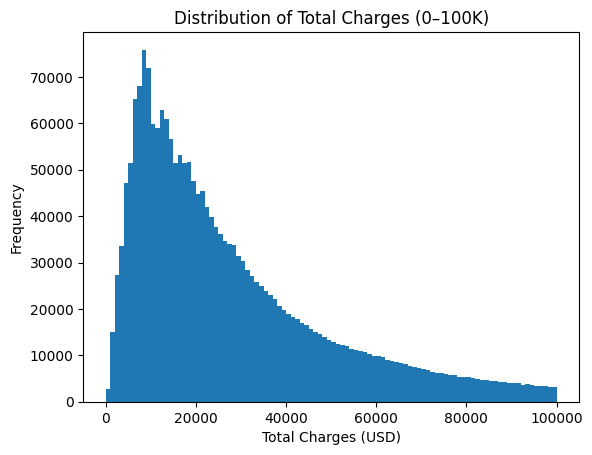

In [47]:
import matplotlib.pyplot as plt

filtered = df_clean[df_clean['total_charges'] <= 100000]

plt.hist(filtered['total_charges'], bins=100)
plt.title("Distribution of Total Charges (0–100K)")
plt.xlabel("Total Charges (USD)")
plt.ylabel("Frequency")
plt.show()

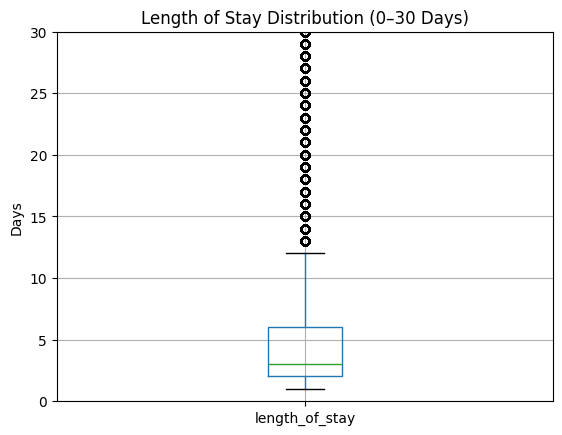

In [48]:
df_clean.boxplot(column='length_of_stay')
plt.ylim(0, 30)  # focus on typical range
plt.title("Length of Stay Distribution (0–30 Days)")
plt.ylabel("Days")
plt.show()

Missingness:

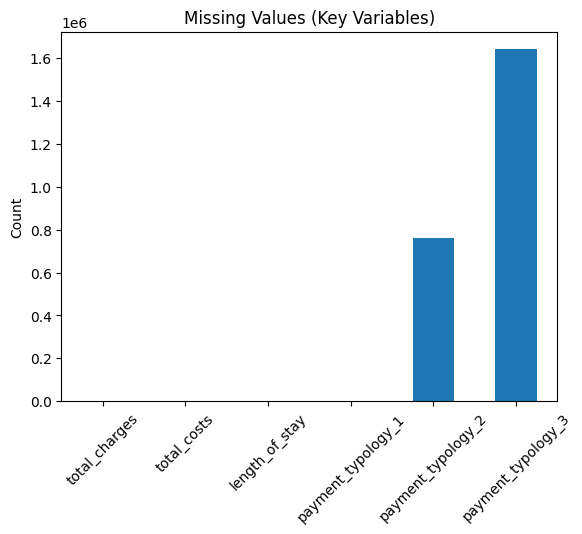

In [50]:
cols = ['total_charges', 'total_costs', 'length_of_stay',
        'payment_typology_1', 'payment_typology_2', 'payment_typology_3']

df_clean[cols].isnull().sum().plot(kind='bar')
plt.title("Missing Values (Key Variables)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()